562245


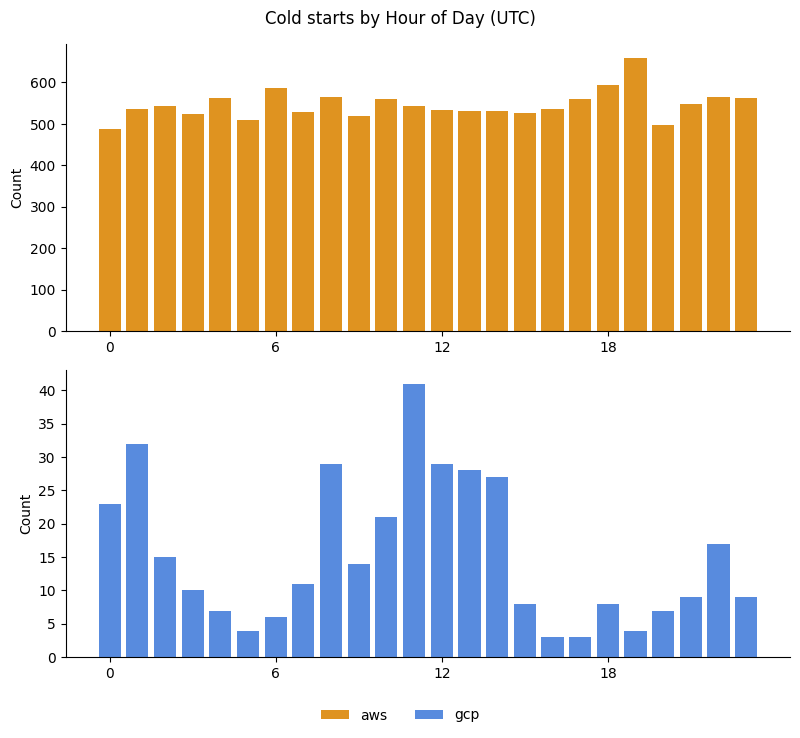

In [278]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.reset_defaults()
pd.set_option('display.width', 1000)
colors = {'aws': '#ff9900', 'gcp': '#4285F4'}
df = pd.read_pickle('../stats-all-latest.pkl')
print(len(df))

# Cold starts, Day 1+
data = df.dropna(subset=['coldStart'])
data = data.loc[(data["timestamp"] > 1733184000000)]

data.loc[:, 'isoDate'] = pd.to_datetime(data['!isoDate']) 
data = data.set_index("isoDate").sort_index()
data["dom"] = data.index.day
data["dow"] = data.index.day_of_week
data["day_name"] = data.index.day_name()
data["hod"] = data.index.hour
data["moh"] = data.index.minute
data["how"] = data["dow"] * 24 + data["hod"]
data["msm"] = data.index.hour * 60 + (data.index.minute)

# Create the catplot with 'providerName' as row and hue
g = sns.catplot(
    data=data,
    kind='count',
    x='hod',
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2,
    height=3.5,
    native_scale=True,
    sharex='row',
    sharey=False,
)
plt.suptitle('Cold starts by Hour of Day (UTC)')

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set(xticks=range(0, 24, 6))
g.set_titles('')
g.set_xlabels('')
g.set_ylabels('Count')
plt.tight_layout()
plt.show()